In [1]:
import base64
import os
import pickle
import time

import numpy as np
import pandas as pd


def to_csv(data, save_dir: str, save_name: str):
    """
    Save the input data (either a DataFrame or a 3D NumPy array) into CSV file(s).

    If the input is a pandas DataFrame, it will be saved directly to the given directory.
    If the input is a 3D NumPy array (with shape [num, time, dim]), each 2D slice (data[i])
    will be saved into a separate subdirectory named 'sample_i'.

    :param data: The data to save, either a pandas DataFrame or a NumPy array of shape (num, time, dim).
    :param save_dir: The root directory where the files will be saved.
    :param save_name: The name of the CSV file(s) to be written.
    :raises TypeError: If the input data type is not supported.
    """
    os.makedirs(save_dir, exist_ok=True)

    if isinstance(data, pd.DataFrame):
        data.to_csv(os.path.join(save_dir, save_name), index=False)

    elif isinstance(data, np.ndarray):
        num = data.shape[0]
        for i in range(num):
            sample_dir = os.path.join(save_dir, f"sample_{i}")
            os.makedirs(sample_dir, exist_ok=True)
            df = pd.DataFrame(data[i])
            df.to_csv(os.path.join(sample_dir, save_name), index=False)

    elif isinstance(data, list):
        num = len(data)
        for i in range(num):
            sample_dir = os.path.join(save_dir, f"sample_{i}")
            os.makedirs(sample_dir, exist_ok=True)
            df = data[i]
            df.to_csv(os.path.join(sample_dir, save_name), index=False)

    else:
        raise TypeError("Unsupported type for data. Must be pd.DataFrame or np.ndarray.")


def decode_data(filepath: str):
    """
    Load the result CSV file and decode the base64-encoded 'inference_data' and 'actual_data' columns.

    :param filepath: Path to the input CSV file containing encoded data.
    :return: None. The decoded data will be saved as CSV files in corresponding folders.
    """
    data = pd.read_csv(filepath)  # Read the CSV file with encoded columns

    for index, row in data.iterrows():
        # Decode base64 strings and deserialize them back to original DataFrames
        decoded_inference_data = base64.b64decode(row["inference_data"])
        decoded_actual_data = base64.b64decode(row["actual_data"])
        inference_data = pickle.loads(decoded_inference_data)
        actual_data = pickle.loads(decoded_actual_data)

        # Construct directory name by removing special characters from model parameters
        file_name = os.path.splitext(row["file_name"])[0]
        model_name = row["model_name"]
        model_params = row["model_params"].translate(str.maketrans('', '', '":, {}'))
        save_dir = f"{file_name}_{model_name}_{model_params}"
        timestamp = f"{int(time.time() * 1000)}"
        save_dir = os.path.join(save_dir, timestamp)
        print(f"Saving data to directory: {save_dir}")

        # Save the decoded data as CSV files
        to_csv(inference_data, save_dir, "inference_data.csv")
        to_csv(actual_data, save_dir, "actual_data.csv")


# Example usage
your_result_csv_path = r"E:\Project\PythonProject\TFB\result\ETTh1\DUET\DUET.1769839093.DESKTOP-FQEO3JL.43480.csv"
decode_data(your_result_csv_path)

Saving data to directory: ETTh1_DUET_CI1batch_size32d_ff512d_model512dropout0.5e_layers1factor3fc_dropout0.1horizon96k1lossMAElr0.0005lradjtype1n_heads1normtruenum_epochs100num_experts2patch_len48patience5seq_len512\1769841333612


In [11]:
import matplotlib.pyplot as plt
csv_path_true = r"E:\Project\PythonProject\TFB\JupyterNotebook\ETTh1_DUET_CI1batch_size32d_ff512d_model512dropout0.5\1769841333612\sample_200\actual_data.csv"
df_true = pd.read_csv(csv_path_true, header=0)
df_true.head()

,0,1,2,3,4,5,6
0,2.478,3.952,-0.213000,2.487,2.772,1.340,10.200
1,-7.301,3.818,-10.412000,2.097,2.711,1.340,10.341
2,-11.052,5.023,-14.143000,3.305,2.924,1.279,10.622
3,-13.530,5.894,-16.167999,4.158,2.772,1.066,11.185
4,-15.539,6.229,-18.407000,4.477,2.437,1.279,10.833


In [12]:
csv_path_pre = r"E:\Project\PythonProject\TFB\JupyterNotebook\ETTh1_DUET_CI1batch_size32d_ff512d_model512dropout0.5\1769841333612\sample_200\inference_data.csv"
df_pre = pd.read_csv(csv_path_pre, header=0)
df_pre.head()

,0,1,2,3,4,5,6
0,5.502237,3.181440,2.506393,1.713261,3.051892,1.345976,9.102087
1,1.286512,3.311363,-1.635601,1.758883,2.807354,1.360965,8.955100
2,-1.103697,3.972097,-4.119752,2.326290,2.892394,1.352338,9.099910
3,-2.759791,4.462274,-5.704118,2.689763,2.859300,1.270197,9.224750
4,-4.922216,4.414854,-7.503689,2.587139,2.334790,1.212917,9.379607


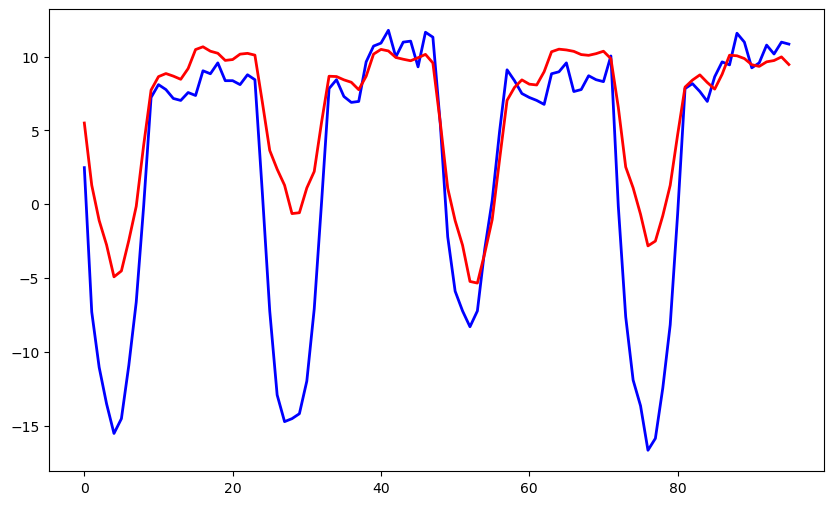

In [13]:
plt.figure(figsize=(10,6))

plt.plot(df_true.iloc[:, 0].values, linewidth=2, color='blue')

plt.plot(df_pre.iloc[:, 0].values, linewidth=2, color='red')